# 05.05 · Naive Bayes

**Objetivo:** entender el modelo que gana con la suposición más descaradamente falsa
de toda la estadística — y ver por qué, aun así, funciona tan bien en texto.

Es el clasificador de spam original: el que llevaba tu bandeja de entrada antes de que
nadie hablara de deep learning. Se entrena en milisegundos y cabe en una servilleta.

📖 Teoría: [5.1 Modelos clásicos](../../../../../docs/02-deep-learning/05-tipos-de-modelo/5.1-modelos-clasicos.md)

In [1]:
# --- Bootstrap: local o Colab ---------------------------------------------
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/TU_USUARIO/dl-lab.git"

if IN_COLAB:
    subprocess.run(["git", "clone", "-q", REPO_URL, "/content/dl-lab"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "/content/dl-lab"], check=True)
    sys.path.insert(0, "/content/dl-lab/src")

print("Ejecutando en:", "Google Colab" if IN_COLAB else "Local (Docker)")

Ejecutando en: Local (Docker)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

from dllab import set_seed

set_seed(42)

42

## 1. El caso de uso

Gestionas el buzón de contacto de una empresa. Cada mañana llegan mensajes de clientes
de verdad mezclados con publicidad basura. Quieres que el filtro los separe solo.

Aquí escribimos el corpus a mano —36 mensajes— para que se pueda **leer entero** y
entender qué está mirando el modelo. Con un corpus real de 50.000 correos el
procedimiento sería idéntico, pero no se vería nada.

In [3]:
spam = [
    "gana dinero rapido desde casa sin esfuerzo",
    "has ganado un premio reclama tu premio ahora",
    "oferta unica compra ya descuento del 90 por ciento",
    "gana dinero facil trabajando desde casa",
    "urgente reclama tu premio antes de que expire",
    "compra ahora oferta limitada ultimas unidades",
    "dinero rapido garantizado sin riesgo pincha aqui",
    "felicidades has sido seleccionado para un premio",
    "credito inmediato sin papeles pincha en el enlace",
    "descuento exclusivo solo hoy compra ya",
    "gana premios cada dia solo tienes que registrarte",
    "oferta increible dinero facil pincha aqui ahora",
    "reclama tu regalo urgente ultimas horas",
    "trabaja desde casa y gana dinero sin experiencia",
    "promocion unica descuento enorme compra urgente",
    "pincha aqui para reclamar tu dinero inmediato",
    "premio garantizado registrate gratis ahora mismo",
    "ultima oportunidad oferta que expira hoy",
]

legitimo = [
    "buenos dias querria consultar el estado de mi pedido",
    "adjunto la factura del mes pasado para revision",
    "podemos mover la reunion del martes a las diez",
    "gracias por la respuesta quedo a la espera del presupuesto",
    "el pedido llego ayer pero faltaba una pieza",
    "necesito el certificado de garantia del producto",
    "confirmo la asistencia a la reunion del jueves",
    "adjunto el informe tecnico que me pediste",
    "buenas tardes cuando estara disponible el repuesto",
    "he recibido el paquete todo correcto muchas gracias",
    "querria cambiar la direccion de envio del pedido",
    "el presupuesto me parece correcto podemos seguir adelante",
    "sigue pendiente la factura de septiembre puedes revisarla",
    "os escribo para pedir informacion sobre el mantenimiento",
    "la reunion se retrasa media hora disculpad las molestias",
    "adjunto los datos fiscales que solicitasteis ayer",
    "necesitamos ampliar el pedido en dos unidades mas",
    "gracias por la visita de ayer quedamos en contacto",
]

mensajes = spam + legitimo
etiquetas = np.array([1] * len(spam) + [0] * len(legitimo))  # 1 = spam, 0 = legítimo

print(f"{len(mensajes)} mensajes: {sum(etiquetas)} spam, {len(etiquetas) - sum(etiquetas)} legítimos")

36 mensajes: 18 spam, 18 legítimos


## 2. Primer problema: un modelo no lee texto

Los modelos comen números. Hay que convertir cada mensaje en un vector, y la forma más
simple de hacerlo es la **bolsa de palabras** (*bag of words*): una columna por cada
palabra del vocabulario, y en cada fila, cuántas veces aparece esa palabra.

El nombre no engaña: se pierde por completo el orden. "el perro muerde al hombre" y
"el hombre muerde al perro" acaban siendo el mismo vector. Guárdate esa objeción, que
es la clave del apartado 8.

In [4]:
vectorizador = CountVectorizer()
X = vectorizador.fit_transform(mensajes)

vocabulario = vectorizador.get_feature_names_out()
print(f"Vocabulario: {len(vocabulario)} palabras distintas")
print(f"Matriz resultante: {X.shape[0]} mensajes × {X.shape[1]} palabras")
print(f"\nPrimeras 15 palabras: {', '.join(vocabulario[:15])}")

Vocabulario: 156 palabras distintas
Matriz resultante: 36 mensajes × 156 palabras

Primeras 15 palabras: 90, adelante, adjunto, ahora, ampliar, antes, aqui, asistencia, ayer, buenas, buenos, cada, cambiar, casa, certificado


In [5]:
# Cómo queda un mensaje concreto
i = 0
fila = X[i].toarray()[0]
presentes = np.where(fila > 0)[0]

print(f'Mensaje: "{mensajes[i]}"\n')
print("Se convierte en un vector de ceros, salvo:")
for j in presentes:
    print(f"  {vocabulario[j]:14} → {fila[j]}")

Mensaje: "gana dinero rapido desde casa sin esfuerzo"

Se convierte en un vector de ceros, salvo:
  casa           → 1
  desde          → 1
  dinero         → 1
  esfuerzo       → 1
  gana           → 1
  rapido         → 1
  sin            → 1


## 3. La idea en una frase

**Para cada clase, mide cuán probable es cada palabra; luego, ante un mensaje nuevo,
multiplica las probabilidades de sus palabras y quédate con la clase que salga mayor.**

El nombre viene del **teorema de Bayes**, que le da la vuelta a la pregunta. Lo que
queremos saber —*dado este mensaje, ¿qué probabilidad hay de que sea spam?*— es
difícil de medir directamente. Lo que sí es fácil de contar es lo contrario: *entre
los mensajes que sabemos que son spam, ¿con qué frecuencia aparece la palabra
"premio"?*

Bayes conecta las dos:

$$P(\text{spam} \mid \text{palabras}) \propto P(\text{spam}) \times P(\text{palabras} \mid \text{spam})$$

## Y el "naive" ¿de dónde sale?

Del segundo factor. Calcular la probabilidad de una **combinación** concreta de
palabras es imposible: harían falta más ejemplos que átomos hay. Así que el modelo
hace una suposición heroica: **que las palabras son independientes entre sí**, y por
tanto la probabilidad del conjunto es el producto de las probabilidades individuales.

Es falso y se sabe. En español, después de "muchas" viene "gracias" mucho más a menudo
de lo que "gracias" aparece por su cuenta. Pero mira lo que pasa igualmente.

## 4. Entrenar

Entrenar es, literalmente, **contar palabras**. No hay descenso de gradiente, no hay
iteraciones, no hay nada que converja.

In [6]:
modelo = MultinomialNB()
modelo.fit(X, etiquetas)

print(f"Acierto en los datos de entrenamiento: {modelo.score(X, etiquetas):.1%}")

Acierto en los datos de entrenamiento: 100.0%


## 5. Probarlo con mensajes nuevos

Estos no están en el corpus. El modelo no los ha visto nunca.

In [7]:
nuevos = [
    "gana dinero facil pincha aqui",
    "buenos dias adjunto la factura de octubre",
    "reclama tu premio urgente",
    "podemos revisar el presupuesto el jueves",
    "oferta unica solo hoy",
    "gracias por el envio del pedido",
]

X_nuevos = vectorizador.transform(nuevos)
pred = modelo.predict(X_nuevos)
prob = modelo.predict_proba(X_nuevos)[:, 1]

for mensaje, p, pr in zip(nuevos, pred, prob):
    etiqueta = "SPAM     " if p == 1 else "legítimo "
    print(f"{etiqueta} ({pr:5.1%} spam)  ← \"{mensaje}\"")

SPAM      (100.0% spam)  ← "gana dinero facil pincha aqui"
legítimo  ( 0.1% spam)  ← "buenos dias adjunto la factura de octubre"
SPAM      (99.8% spam)  ← "reclama tu premio urgente"
legítimo  ( 0.3% spam)  ← "podemos revisar el presupuesto el jueves"
SPAM      (99.4% spam)  ← "oferta unica solo hoy"
legítimo  ( 0.1% spam)  ← "gracias por el envio del pedido"


## 6. Mirar por dentro: qué palabras lo delatan

El modelo guarda, para cada palabra, cuán probable es en cada clase. Comparando las
dos podemos sacar las palabras más acusatorias y las más inocentes.

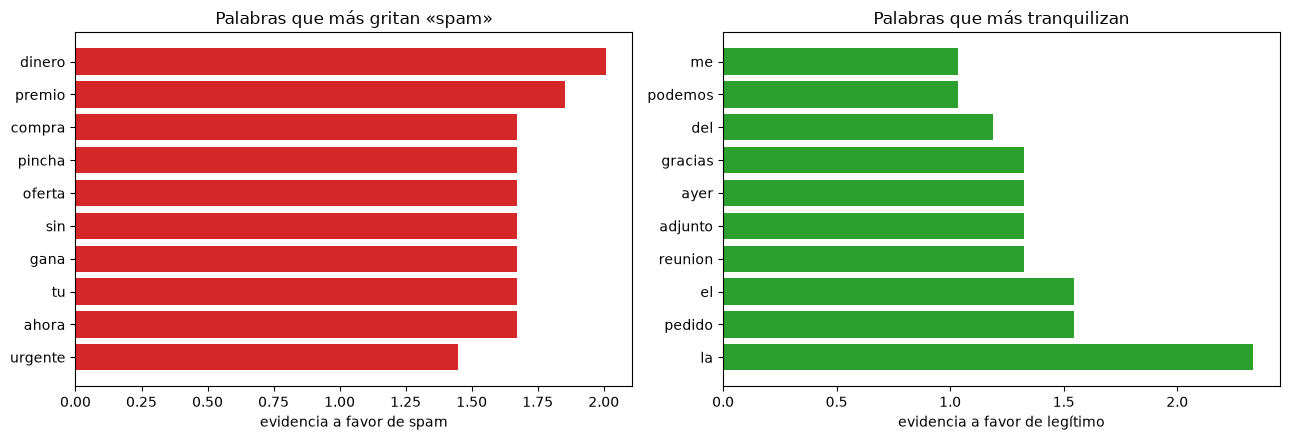

In [8]:
# feature_log_prob_[clase] = log P(palabra | clase)
log_spam = modelo.feature_log_prob_[1]
log_ok = modelo.feature_log_prob_[0]
evidencia = log_spam - log_ok  # positivo → apunta a spam

orden = np.argsort(evidencia)
mas_spam = orden[-10:]
mas_ok = orden[:10]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh([vocabulario[i] for i in mas_spam], evidencia[mas_spam], color="tab:red")
axes[0].set_title("Palabras que más gritan «spam»")
axes[0].set_xlabel("evidencia a favor de spam")
axes[1].barh([vocabulario[i] for i in mas_ok], -evidencia[mas_ok], color="tab:green")
axes[1].set_title("Palabras que más tranquilizan")
axes[1].set_xlabel("evidencia a favor de legítimo")
plt.tight_layout()
plt.show()

Nada sorprendente, y eso es buena señal: el modelo ha encontrado justo las palabras que
cualquiera habría señalado a mano. Como los árboles, **se puede auditar**.

## 7. Detalle importante: el suavizado de Laplace

¿Qué pasa con una palabra que solo aparece en mensajes legítimos? Su probabilidad en
spam sería **cero**, y como el modelo multiplica probabilidades, un solo cero anularía
el resultado entero: un mensaje con esa palabra jamás podría ser spam, por muchas
señales de spam que llevara.

La solución es de una simplicidad desarmante: **empezar a contar desde 1 en vez de
desde 0**. Es el parámetro `alpha`.

In [9]:
for alpha in [1.0, 1e-10]:
    m = MultinomialNB(alpha=alpha).fit(X, etiquetas)
    p = m.predict_proba(vectorizador.transform(["gana dinero facil llamando al telefono"]))[0, 1]
    print(f"alpha={alpha:<8} → probabilidad de spam: {p:.6%}")

alpha=1.0      → probabilidad de spam: 99.215674%
alpha=1e-10    → probabilidad de spam: 100.000000%


Con `alpha` casi nulo, el modelo se vuelve tajante y frágil: una única palabra no vista
en spam basta para descartarlo. `alpha=1` (el valor por defecto) reparte un poco de
probabilidad a todo y hace el modelo mucho más estable.

## 8. Por qué funciona si la suposición es falsa

Aquí está lo interesante. Las palabras **no** son independientes, así que las
probabilidades que calcula Naive Bayes están mal. Y sin embargo clasifica bien.

El motivo: para acertar la clase no hace falta que la probabilidad sea correcta, solo
que **la clase ganadora sea la correcta**. El modelo puede decirte "99,99 % spam"
cuando la probabilidad real es del 70 % — el número está mal, la decisión está bien.

Es un recordatorio útil de que **un modelo puede ser útil sin ser cierto**. Solo hay
que no fiarse de sus probabilidades como si fueran probabilidades de verdad: están mal
calibradas casi siempre.

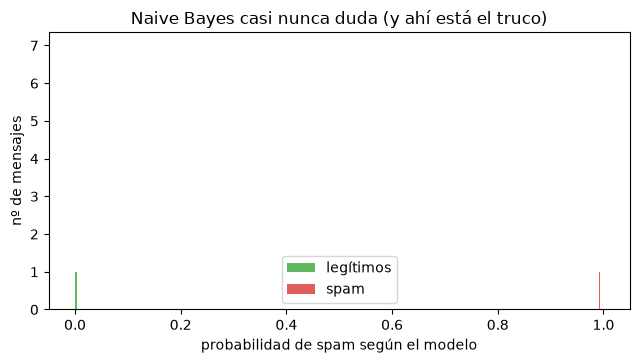

Mensajes con probabilidad entre 0,1 y 0,9: 0 de 36


In [10]:
# Ilustración: mira lo extremas que son las probabilidades
probs = modelo.predict_proba(X)[:, 1]

plt.figure(figsize=(7.5, 3.6))
plt.hist(probs[etiquetas == 0], bins=20, alpha=0.75, label="legítimos", color="tab:green")
plt.hist(probs[etiquetas == 1], bins=20, alpha=0.75, label="spam", color="tab:red")
plt.xlabel("probabilidad de spam según el modelo")
plt.ylabel("nº de mensajes")
plt.title("Naive Bayes casi nunca duda (y ahí está el truco)")
plt.legend()
plt.show()

print(f"Mensajes con probabilidad entre 0,1 y 0,9: {np.sum((probs > 0.1) & (probs < 0.9))} de {len(probs)}")

Todo pegado a los extremos. El modelo está **sobreconfiado** — consecuencia directa de
multiplicar probabilidades como si fueran independientes cuando no lo son.

## 9. Cuándo usarlo y cuándo no

**Úsalo cuando:**

- Clasificas **texto** y quieres algo que funcione hoy: spam, sentimiento, temática.
- Tienes muchísimas variables y pocos ejemplos. Es de los pocos modelos que aguanta
  tener más columnas que filas.
- Necesitas velocidad extrema: entrenar es contar, y se puede actualizar mensaje a
  mensaje sin reentrenar desde cero.
- Quieres una **línea base** en text classification. Que un modelo grande no la bata
  pasa más de lo que parece.

**No lo uses cuando:**

- Necesitas probabilidades fiables para decidir umbrales o costes.
- El orden y el contexto importan: negaciones, ironía, "no me gusta nada" frente a
  "me gusta". Ahí hacen falta [modelos de secuencia y atención](../../../docs/02-deep-learning/05-tipos-de-modelo/5.3.4-atencion-y-transformer.md).
- Las variables están muy correlacionadas entre sí: la suposición ingenua deja de ser
  inofensiva y empieza a hacer daño.

## 10. Prueba tú

1. Añade a `nuevos` un mensaje con palabras que no estén en el vocabulario. ¿Qué
   predice? ¿Por qué esa probabilidad?
2. Escribe un mensaje legítimo que contenga "oferta" y "descuento" (por ejemplo, un
   cliente preguntando por una oferta real). ¿Lo marca como spam? Eso es un **falso
   positivo**, y en un filtro de correo es el error caro.
3. Cambia `CountVectorizer` por `TfidfVectorizer`. ¿Cambian las palabras más
   delatoras?
4. Prueba `CountVectorizer(ngram_range=(1, 2))` para que cuente también pares de
   palabras. Acabas de devolverle un poco del orden que la bolsa de palabras tiraba.